In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
apple = yf.download("AAPL", start="2019-01-01", end="2024-01-01")

apple.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503727,37.724590,36.627404,36.784146,148158800
2019-01-03,33.768070,34.606394,33.722947,34.193168,365248800
2019-01-04,35.209614,35.278487,34.150430,34.323794,234428400
2019-01-07,35.131237,35.344976,34.649142,35.314102,219111200
2019-01-08,35.800949,36.055060,35.271357,35.518341,164101200


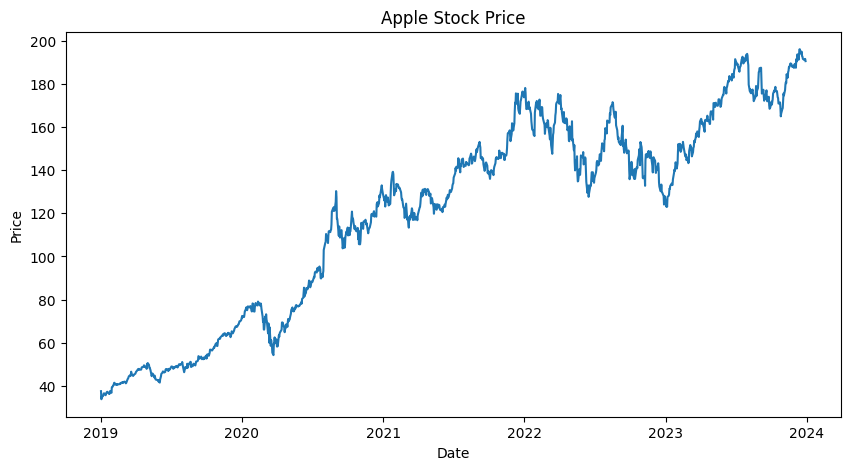

In [3]:
plt.figure(figsize=(10,5))
plt.plot(apple["Close"])
plt.title("Apple Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [4]:
apple["Return"] = apple["Close"].pct_change()

apple.head()

Price,Close,High,Low,Open,Volume,Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2019-01-02,37.503727,37.724590,36.627404,36.784146,148158800,NaN
2019-01-03,33.768070,34.606394,33.722947,34.193168,365248800,-0.099608
2019-01-04,35.209614,35.278487,34.150430,34.323794,234428400,0.042690
2019-01-07,35.131237,35.344976,34.649142,35.314102,219111200,-0.002226
2019-01-08,35.800949,36.055060,35.271357,35.518341,164101200,0.019063


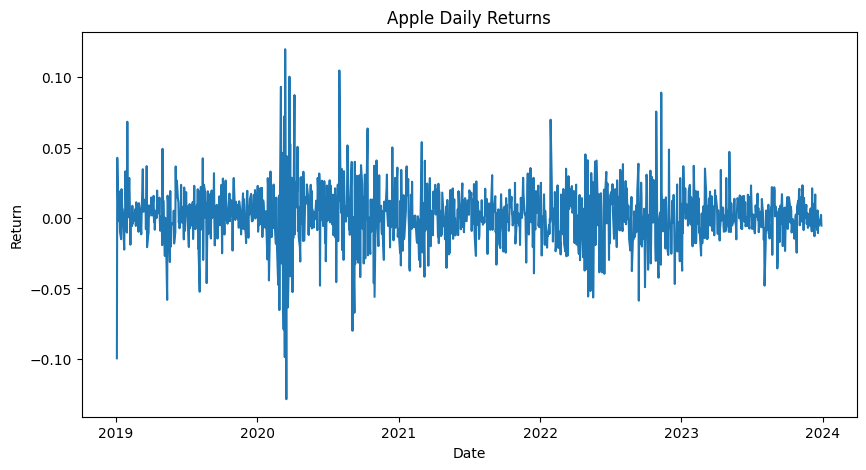

In [5]:
plt.figure(figsize=(10,5))
plt.plot(apple["Return"])
plt.title("Apple Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

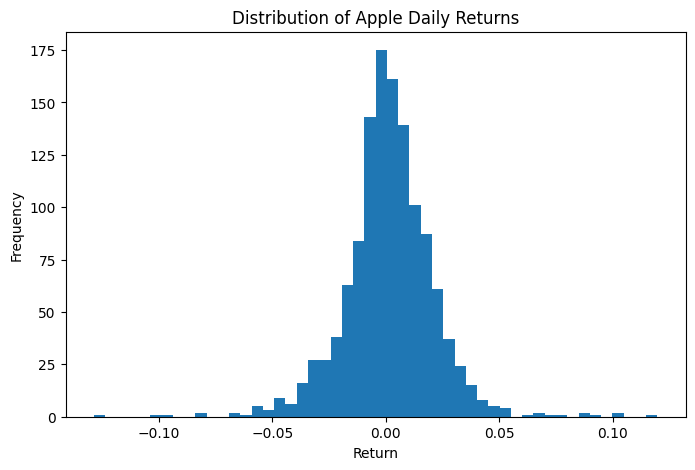

In [6]:
plt.figure(figsize=(8,5))
plt.hist(apple["Return"].dropna(), bins=50)
plt.title("Distribution of Apple Daily Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

In [7]:
volatility = apple["Return"].std()

print("Daily Volatility:", volatility)

Daily Volatility: 0.02030585207173156


In [8]:
stocks = yf.download(["AAPL","MSFT","GOOGL","TSLA"], start="2019-01-01", end="2024-01-01")["Close"]

stocks.head()

[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,GOOGL,MSFT,TSLA
Date,,,,
2019-01-02,37.503727,52.338547,94.397148,20.674667
2019-01-03,33.768070,50.888988,90.924469,20.024000
2019-01-04,35.209614,53.499275,95.153290,21.179333
2019-01-07,35.131237,53.392586,95.274666,22.330667
2019-01-08,35.800949,53.861538,95.965446,22.356667


<Figure size 1200x600 with 0 Axes>

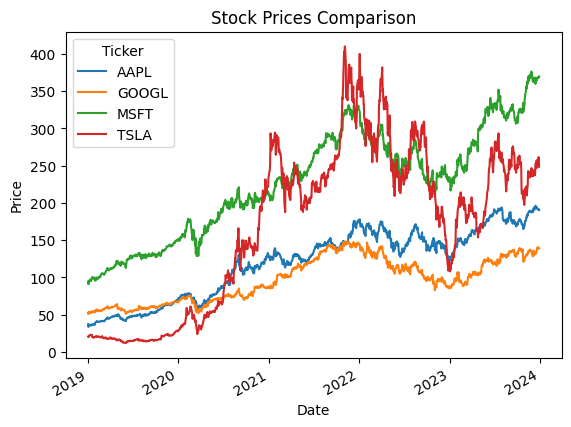

In [9]:
plt.figure(figsize=(12,6))
stocks.plot()
plt.title("Stock Prices Comparison")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [10]:
returns = stocks.pct_change()

returns.head()

Ticker,AAPL,GOOGL,MSFT,TSLA
Date,,,,
2019-01-02,NaN,NaN,NaN,NaN
2019-01-03,-0.099608,-0.027696,-0.036788,-0.031472
2019-01-04,0.042690,0.051294,0.046509,0.057697
2019-01-07,-0.002226,-0.001994,0.001276,0.054361
2019-01-08,0.019063,0.008783,0.007250,0.001164


In [11]:
correlation = returns.corr()

print(correlation)

Ticker      AAPL     GOOGL      MSFT      TSLA
Ticker                                        
AAPL    1.000000  0.674939  0.758621  0.488406
GOOGL   0.674939  1.000000  0.759000  0.408303
MSFT    0.758621  0.759000  1.000000  0.453118
TSLA    0.488406  0.408303  0.453118  1.000000


In [15]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\rohan\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


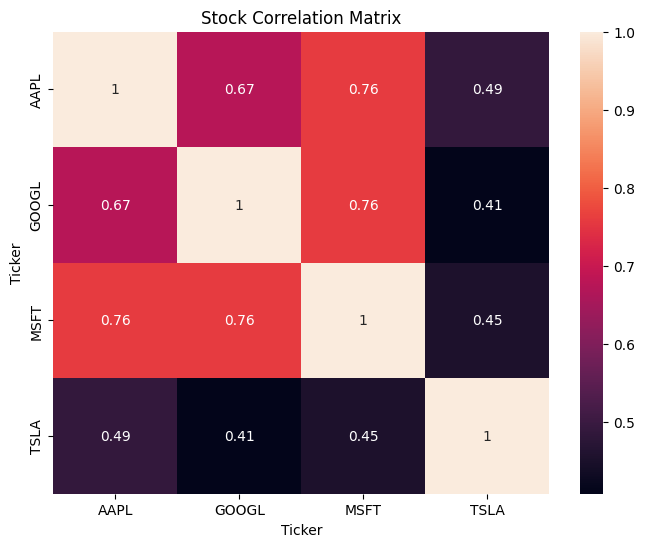

In [16]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True)
plt.title("Stock Correlation Matrix")
plt.show()

In [17]:
weights = np.array([0.25,0.25,0.25,0.25])

portfolio_return = np.sum(returns.mean() * weights) * 252
portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov()*252, weights)))

print("Portfolio Return:", portfolio_return)
print("Portfolio Volatility:", portfolio_volatility)

Portfolio Return: 0.4131106770035601
Portfolio Volatility: 0.32615264922194903


In [18]:
num_ports = 1000

all_weights = []
returns_arr = []
volatility_arr = []

In [19]:
for i in range(num_ports):

    weights = np.random.random(4)
    weights = weights / np.sum(weights)

    all_weights.append(weights)

    port_return = np.sum(returns.mean() * weights) * 252
    returns_arr.append(port_return)

    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov()*252, weights)))
    volatility_arr.append(port_vol)

In [20]:
returns_arr = np.array(returns_arr)
volatility_arr = np.array(volatility_arr)

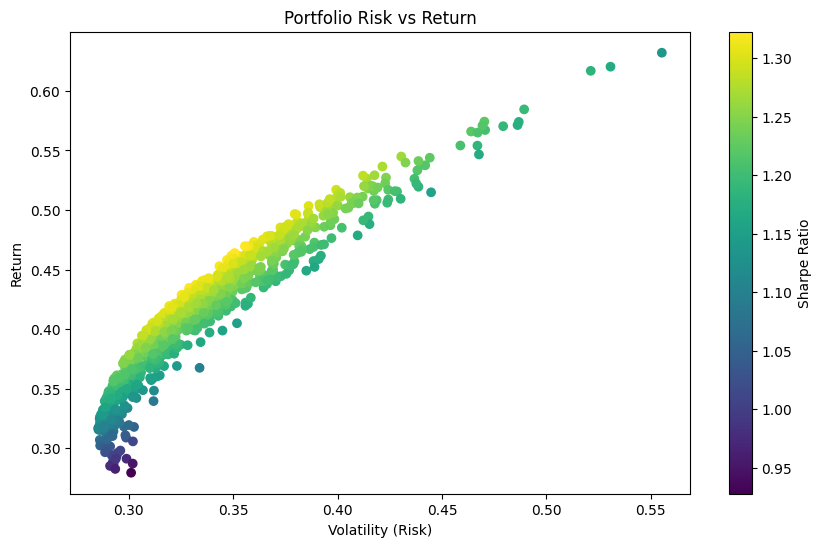

In [21]:
plt.figure(figsize=(10,6))
plt.scatter(volatility_arr, returns_arr, c=returns_arr/volatility_arr)
plt.xlabel("Volatility (Risk)")
plt.ylabel("Return")
plt.title("Portfolio Risk vs Return")
plt.colorbar(label="Sharpe Ratio")
plt.show()

In [22]:
sharpe_ratio = returns_arr / volatility_arr

In [23]:
max_sharpe_index = sharpe_ratio.argmax()

best_return = returns_arr[max_sharpe_index]
best_volatility = volatility_arr[max_sharpe_index]
best_weights = all_weights[max_sharpe_index]

print("Best Portfolio Return:", best_return)
print("Best Portfolio Volatility:", best_volatility)
print("Best Portfolio Weights:", best_weights)

Best Portfolio Return: 0.46384387946643396
Best Portfolio Volatility: 0.35067783662670915
Best Portfolio Weights: [0.45105948 0.00298069 0.24240732 0.30355251]


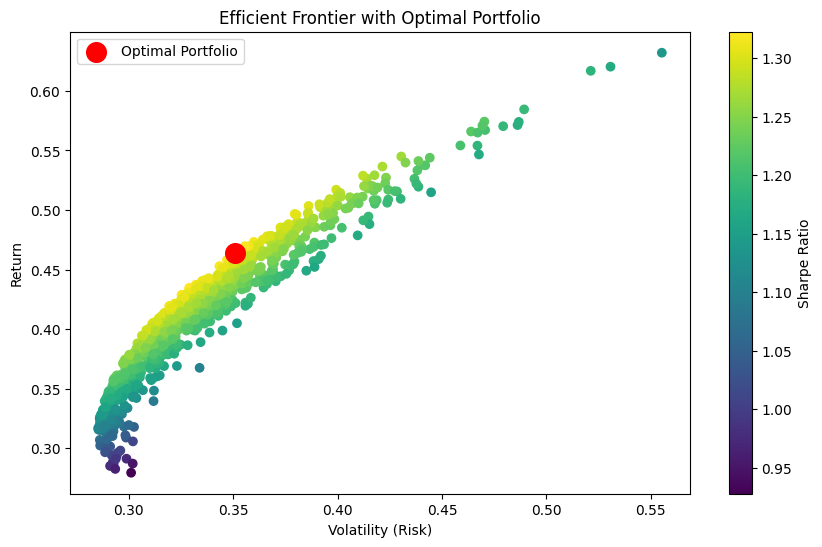

In [24]:
plt.figure(figsize=(10,6))
plt.scatter(volatility_arr, returns_arr, c=sharpe_ratio)
plt.colorbar(label="Sharpe Ratio")

plt.scatter(best_volatility, best_return, color="red", s=200, label="Optimal Portfolio")

plt.xlabel("Volatility (Risk)")
plt.ylabel("Return")
plt.title("Efficient Frontier with Optimal Portfolio")
plt.legend()

plt.show()

In [25]:
stocks.columns

Index(['AAPL', 'GOOGL', 'MSFT', 'TSLA'], dtype='str', name='Ticker')

In [26]:
portfolio = pd.DataFrame({
    "Stock": stocks.columns,
    "Weight": best_weights
})

portfolio

,Stock,Weight
0,AAPL,0.451059
1,GOOGL,0.002981
2,MSFT,0.242407
3,TSLA,0.303553


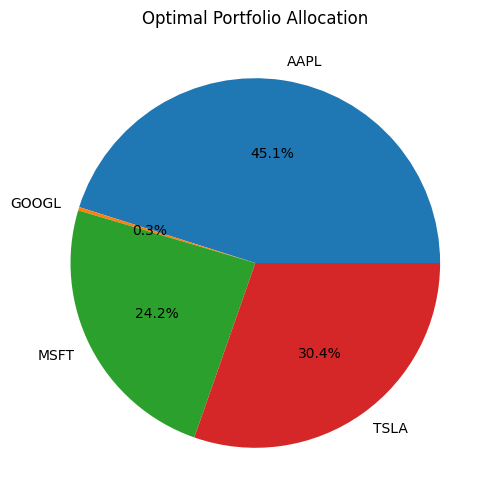

In [27]:
plt.figure(figsize=(6,6))
plt.pie(best_weights, labels=stocks.columns, autopct="%1.1f%%")
plt.title("Optimal Portfolio Allocation")
plt.show()

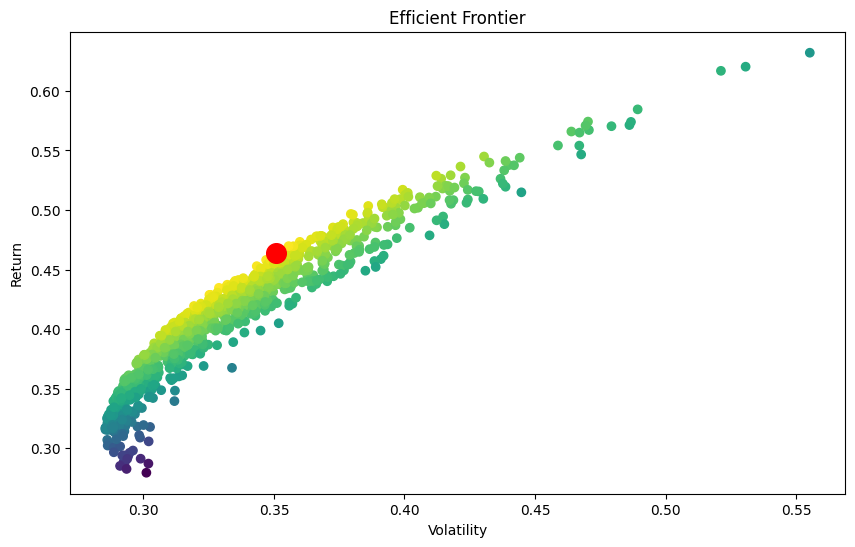

In [28]:
plt.figure(figsize=(10,6))
plt.scatter(volatility_arr, returns_arr, c=sharpe_ratio)
plt.scatter(best_volatility, best_return, color="red", s=200)

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Efficient Frontier")

plt.savefig("efficient_frontier.png")
plt.show()